In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/AIE/CV/CVE/CVE/5_train.zip", 'r') as zip_ref:        # get the path for train.zip using copypath. paste the link within the quotation
     # creates new folder 'cats_dogs_images' and saves all images present in train.zip
    zip_ref.extractall("/content/drive/MyDrive/AIE/CV/CVE/CVE")  # create a new folder, rename it and get the path of it using copypath.. paste the link here

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import cv2

In [9]:
import os
files_list = os.listdir("/content/drive/MyDrive/AIE/CV/CVE/CVE/train")

# Count the number of files
num_files = len(files_list)
print(num_files)

25001


In [10]:
print(files_list[-10:])  # Print the first 10 file names to verify

['dog.9990.jpg', 'dog.9991.jpg', 'dog.9992.jpg', 'dog.9993.jpg', 'dog.9994.jpg', 'dog.9995.jpg', 'dog.9996.jpg', 'dog.9997.jpg', 'dog.9998.jpg', 'dog.9999.jpg']


In [11]:
cat = 0
dog = 0
for word in files_list:
    if "cat" in word.lower():
        cat += 1
    elif "dog" in word.lower():
        dog += 1
print(f"Number of cat images: {cat}")
print(f"Number of dog images: {dog}")

Number of cat images: 12500
Number of dog images: 12500


In [13]:
import pathlib,shutil
original_dir = pathlib.Path("/content/drive/MyDrive/AIE/CV/CVE/CVE/train")
new_base_dir = pathlib.Path("/content/drive/MyDrive/AIE/CV/CVE/CVE/My_images")

def make_subset(subset_name, start_index, end_index):
    for category in ["cat","dog"]:
        dir = new_base_dir / subset_name / category
        os.makedirs(dir, exist_ok=True)# Create the directory if it doesn't exist
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)


make_subset("train", start_index=0, end_index=2000)
make_subset("validation", start_index=2000, end_index=2500)
make_subset("test", start_index=2500, end_index=3000)

(334, 499, 3)


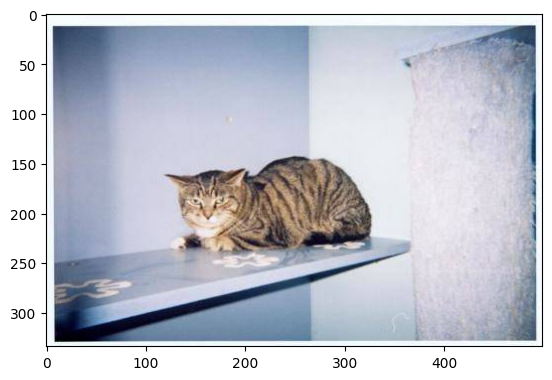

In [15]:
img = plt.imread("/content/drive/MyDrive/AIE/CV/CVE/CVE/train/cat.2502.jpg")
plt.imshow(img)
print(img.shape)

In [16]:
labels = ["cat", "dog"]
image_size = (224,224) # Why 224? 👉 Standard CNN size (VGG, ResNet etc)
def get_data(data_dir):
    data = []
    for label in labels:
        path=os.path.join(data_dir, label)
        print("Reading folder:", path)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_array = plt.imread(os.path.join(path, img)) #coverts bgr to rgb
                resized_array = cv2.resize(img_array, image_size)
                data.append([resized_array, class_num])
            except Exception as e:
                print(f"Error loading image {img}: {e}")
    return np.array(data, dtype=object)



In [ ]:
# for label in labels:
#     path = os.path.join(data_dir, label)
#     print("Reading folder:", path)

In [17]:
print(os.listdir("/content/drive/MyDrive/AIE/CV/CVE/CVE/My_images/train"))

['cat', 'dog']


In [18]:
train = get_data("/content/drive/MyDrive/AIE/CV/CVE/CVE/My_images/train")
validation = get_data("/content/drive/MyDrive/AIE/CV/CVE/CVE/My_images/validation")
test = get_data("/content/drive/MyDrive/AIE/CV/CVE/CVE/My_images/test")

Reading folder: /content/drive/MyDrive/AIE/CV/CVE/CVE/My_images/train/cat
Reading folder: /content/drive/MyDrive/AIE/CV/CVE/CVE/My_images/train/dog
Reading folder: /content/drive/MyDrive/AIE/CV/CVE/CVE/My_images/validation/cat
Reading folder: /content/drive/MyDrive/AIE/CV/CVE/CVE/My_images/validation/dog
Reading folder: /content/drive/MyDrive/AIE/CV/CVE/CVE/My_images/test/cat
Reading folder: /content/drive/MyDrive/AIE/CV/CVE/CVE/My_images/test/dog


In [19]:
labels = [item[1] for item in train]
import numpy as np
print(np.unique(labels, return_counts=True))

(array([0, 1]), array([2000, 2000]))


#seperate features and labels

In [20]:
x_train,y_train = [],[]
x_val,y_val = [],[]
x_test,y_test = [],[]

for feature, label in train:
    x_train.append(np.array(feature))
    y_train.append(int(label))
for feature, label in validation:
    x_val.append(np.array(feature))
    y_val.append(int(label))
for feature, label in test:
    x_test.append(np.array(feature))
    y_test.append(int(label))



In [ ]:
# X = np.loadtxt('input.csv', delimiter=',')
# X = np.append(X, np.loadtxt('input_test.csv', delimiter=','), axis=0)
# Y = np.loadtxt('labels.csv', delimiter=',')
# Y = np.append(Y, np.loadtxt('labels_test.csv', delimiter=','), axis=0)


In [21]:
# X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.2, random_state=42)
# X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

print("Training set size:", train.shape[0])
print("Validation set size:",validation.shape[0])
print("Test set size:", test.shape[0])



Training set size: 4000
Validation set size: 1000
Test set size: 1000


## Resizing/Reshaping

In [ ]:
# X_train = X_train.reshape(len(X_train),100,100,3)
# X_test = X_test.reshape((len(X_test),100,100,3))
# X_val = X_val.reshape((len(X_val),100,100,3))
# Y_train = Y_train.reshape(len(Y_train),1)
# Y_test = Y_test.reshape(len(Y_test),1)
# Y_val = Y_val.reshape(len(Y_val),1)

In [ ]:
# print(x_train.shape)
# print(y_train.shape)
# print(x_test.shape)
# print(y_test.shape)
# print(x_val.shape)
# print(y_val.shape)

# Now Rescalling it between 0 -- 1

In [22]:
#NOrmalization
x_train = np.array(x_train).astype('float32') / 255
x_val = np.array(x_val).astype('float32') / 255
y_train = np.array(y_train)
y_val = np.array(y_val)
x_test = np.array(x_test).astype('float32') / 255
y_test = np.array(y_test)

In [23]:
print(x_train[1])
print(y_train[1])

[[[0.15294118 0.17254902 0.15686275]
  [0.15686275 0.17254902 0.16470589]
  [0.16078432 0.1764706  0.17254902]
  ...
  [0.827451   0.8117647  0.70980394]
  [0.8        0.7882353  0.6627451 ]
  [0.7882353  0.7764706  0.6392157 ]]

 [[0.15686275 0.1764706  0.16078432]
  [0.15686275 0.17254902 0.16470589]
  [0.16078432 0.1764706  0.16862746]
  ...
  [0.8        0.78431374 0.68235296]
  [0.78431374 0.77254903 0.6509804 ]
  [0.7764706  0.7607843  0.6313726 ]]

 [[0.15294118 0.17254902 0.15686275]
  [0.15294118 0.16862746 0.16078432]
  [0.14901961 0.16470589 0.16078432]
  ...
  [0.77254903 0.75686276 0.6627451 ]
  [0.78039217 0.7607843  0.64705884]
  [0.7921569  0.77254903 0.6509804 ]]

 ...

 [[0.11764706 0.10980392 0.11372549]
  [0.10196079 0.09411765 0.10196079]
  [0.09019608 0.08235294 0.08627451]
  ...
  [0.17254902 0.12156863 0.09803922]
  [0.15294118 0.10588235 0.08235294]
  [0.19607843 0.15294118 0.12941177]]

 [[0.1254902  0.11764706 0.11764706]
  [0.10980392 0.10196079 0.10588235]


1


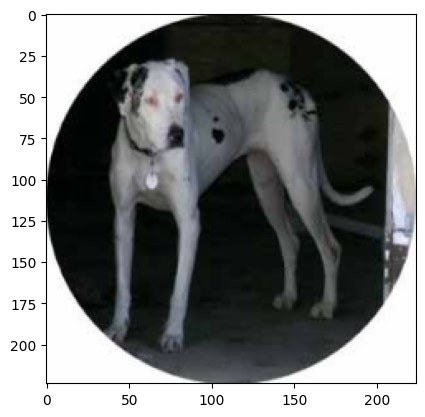

In [24]:
idx = random.randint(0, len(x_train))
plt.imshow(x_train[idx])
print(y_train[idx])

In [25]:
print(y_train.shape)

(4000,)


In [33]:
## Generating data or images during runtime for training purpose.DO not do it for testing
datagen = ImageDataGenerator(
        featurewise_center=True,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range = 30,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.2, # Randomly zoom image
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip = True,  # randomly flip images
        vertical_flip=False)  # randomly flip images
datagen.fit(x_train)

## Model Creation

In [34]:
# We can use either Sequential API or Functional API to build the model. Here we will use Sequential API.
model = Sequential()
model.add(Conv2D(32, 3, padding="same", activation="relu", input_shape=(224, 224, 3)))
model.add(MaxPool2D())

model.add(Conv2D(64, 3, padding="same", activation="relu"))
model.add(MaxPool2D())

model.add(Conv2D(128, 3, padding="same", activation="relu"))
model.add(MaxPool2D())
model.add(Dropout(0.5))  # Stronger regularization

model.add(Flatten())
model.add(Dense(256, activation="relu"))  # Increased capacity
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))  # Binary classification

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,783,873 (98.36 MB)

 Trainable params: 25,783,873 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

✅ What are Callbacks? (simple)

Callbacks = automatic actions during training

They help:

stop overfitting

save best model

adjust learning rate

Think:
👉 “If validation stops improving → stop training”

In [35]:
early_stopping = EarlyStopping(
    monitor='val_loss', # we use moniter val_loss because we want to stop the training when the validation loss starts to increase. If we use monitor='loss' then the training will stop when the training loss starts to increase which is not what we want.
    patience=5,
    restore_best_weights=True)
checkpoint = ModelCheckpoint(
    'best_model.h5',
    verbose=1,
    monitor='val_loss',
    save_best_only=True,
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Model compling and fitting

In [36]:
# We need to add cost funtion and backpropagation algorithm to train the model. We can use binary_crossentropy as the cost function and adam as the optimizer.
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [37]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping, checkpoint, reduce_lr],
    shuffle=True
)


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5087 - loss: 1.0350
Epoch 1: val_loss improved from inf to 0.69575, saving model to best_model.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 221ms/step - accuracy: 0.5088 - loss: 1.0330 - val_accuracy: 0.5000 - val_loss: 0.6957 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5465 - loss: 0.6883
Epoch 2: val_loss improved from 0.69575 to 0.67643, saving model to best_model.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step - accuracy: 0.5466 - loss: 0.6883 - val_accuracy: 0.5960 - val_loss: 0.6764 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6050 - loss: 0.6625
Epoch 3: val_loss improved from 0.67643 to 0.64821, saving model to best_model.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 175ms/step - accuracy: 0.6049 - loss: 0.6625 - val_accuracy: 0.6270 - val_loss: 0.6482 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6754 - loss: 0.6105
Epoch 4: val_loss improved from 0.64821 to 0.57585, saving model to best_model.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.6755 - loss: 0.6105 - val_accuracy: 0.6810 - val_loss: 0.5759 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7258 - loss: 0.5502
Epoch 5: val_loss did not improve from 0.57585
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.7257 - loss: 0.5502 - val_accuracy: 0.6960 - val_loss: 0.5795 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7459 - loss: 0.5249
Epoch 6: val_loss improved from 0.57585 to 0.56324, saving model to best_model.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.7459 - loss: 0.5250 - val_accuracy: 0.7090 - val_loss: 0.5632 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7725 - loss: 0.4814
Epoch 7: val_loss did not improve from 0.56324
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.7725 - loss: 0.4814 - val_accuracy: 0.7090 - val_loss: 0.5723 - learning_rate: 0.0010
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7960 - loss: 0.4539
Epoch 8: val_loss did not improve from 0.56324
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.7959 - loss: 0.4539 - val_accuracy: 0.7190 - val_loss: 0.5676 - learning_rate: 0.0010
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8199 - loss: 0.3905
Epoch 9: val_loss did not improve from 0.56324
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.8199 - loss: 0.3904 - val_accuracy: 0.7140 - val_loss: 0.6139 - learning_rate: 0.0010
Epoch 10/50
125/125 ━━━━━━━━

In [63]:
# Evaluate on test set
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/AIE/CV/CVE/CVE/My_images/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1000 images belonging to 2 classes.


In [65]:
from sklearn.metrics import accuracy_score
# Load best model weights
# model.load_weights('model.weights.best.keras')

# Evaluate on validation or test set
# val_loss, val_acc = model.evaluate(x_val, y_val)
# print(f"Restored model accuracy on validation set: {val_acc:.2f}")

# Predict
pred_probs = model.predict(test_generator)

# Convert sigmoid outputs to binary labels (0 or 1)
pred_classes = (pred_probs > 0.5).astype(int).reshape(-1)

# True labels
true_classes = test_generator.classes # shows actual output present in test folder

# Evaluate
test_accuracy = accuracy_score(true_classes, pred_classes)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step
Test Accuracy: 65.60%


In [66]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - accuracy: 0.6836 - loss: 0.6103
Test Accuracy: 0.656000018119812
Test Loss: 0.6246162056922913


In [67]:
pred_probs = model.predict(test_generator)
print(pred_probs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step
[[0.36249676]
 [0.4981735 ]
 [0.07362853]
 [0.29687917]
 [0.33193153]
 [0.7481335 ]
 [0.10711633]
 [0.29738513]
 [0.9163964 ]
 [0.22736534]
 [0.5054733 ]
 [0.05076028]
 [0.5610082 ]
 [0.4467711 ]
 [0.3266085 ]
 [0.3182434 ]
 [0.12485087]
 [0.09167996]
 [0.5214639 ]
 [0.6715102 ]
 [0.72746634]
 [0.20000406]
 [0.08048922]
 [0.5615151 ]
 [0.26734215]
 [0.21890336]
 [0.24729843]
 [0.02540956]
 [0.18120737]
 [0.8015363 ]
 [0.2676604 ]
 [0.32184103]
 [0.7560021 ]
 [0.5564276 ]
 [0.12265085]
 [0.53766054]
 [0.3049287 ]
 [0.5178514 ]
 [0.2959636 ]
 [0.3035153 ]
 [0.21732469]
 [0.8363664 ]
 [0.57166976]
 [0.08457784]
 [0.34907654]
 [0.45481768]
 [0.5852081 ]
 [0.43125588]
 [0.3717848 ]
 [0.5156144 ]
 [0.23895024]
 [0.31790578]
 [0.24007988]
 [0.4117499 ]
 [0.1272716 ]
 [0.25084108]
 [0.3303038 ]
 [0.0477358 ]
 [0.1631289 ]
 [0.14016373]
 [0.6599196 ]
 [0.96897775]
 [0.6956418 ]
 [0.0115766 ]
 [0.7539915 ]
 [0.3608877 ]
 [0.63941413]
 [0.4207807 ]
 [0.842

In [72]:
pred_classes = (pred_probs > 0.5).astype("int32")
pred_classes

array([[0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
    

# Model Evaluation

In [38]:
model.evaluate(x_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7068 - loss: 0.5990


[0.6270169019699097, 0.6650000214576721]

# Model Prediction ....

/tmp/ipython-input-1926830417.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = class_names[int(pred_classes[idx])]


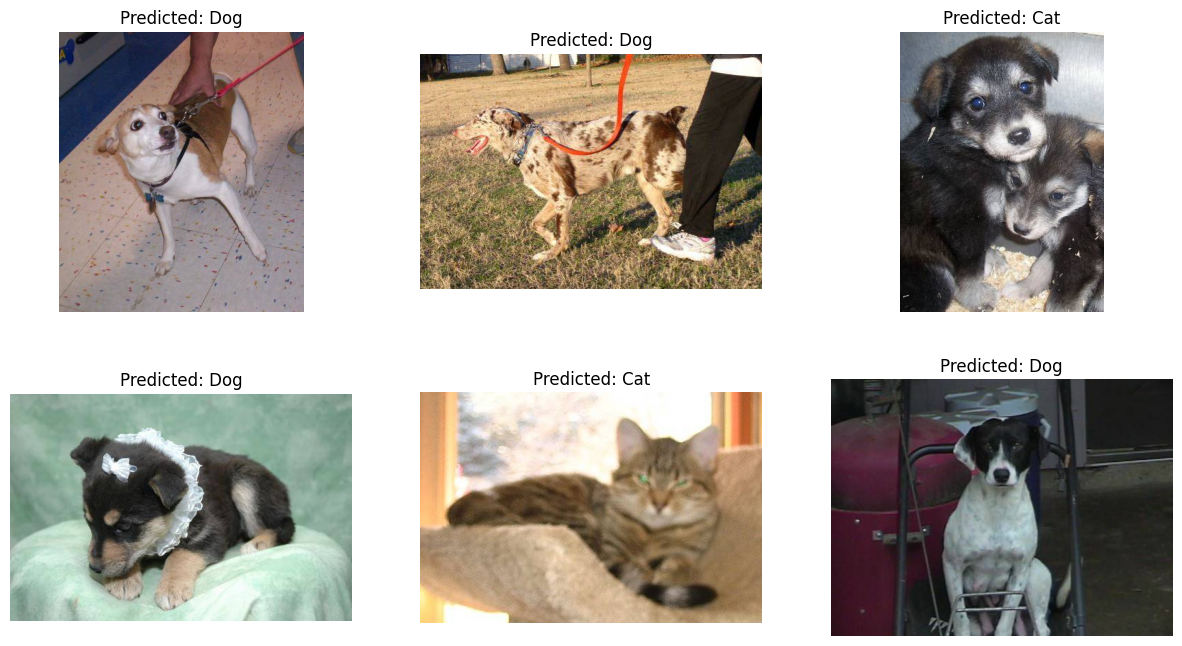

In [71]:
import matplotlib.pyplot as plt
import random

class_names = ['Cat', 'Dog']

# Get filepaths
image_files = test_generator.filepaths

# Pick random images
random_indices = random.sample(range(len(image_files)), 6)

plt.figure(figsize=(15,8))

for i, idx in enumerate(random_indices):

    img = plt.imread(image_files[idx])

    plt.subplot(2,3,i+1)
    plt.imshow(img)

    pred_label = class_names[int(pred_classes[idx])]

    plt.title(f"Predicted: {pred_label}")
    plt.axis("off")

plt.show()


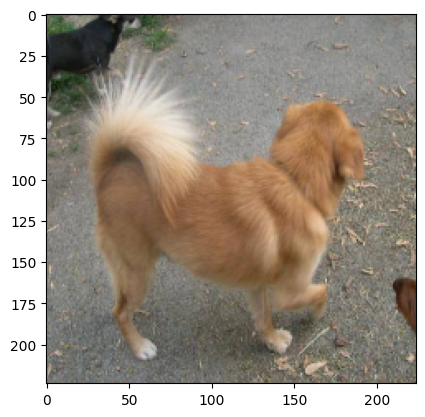

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Our model says it is : dog


In [62]:
idx2 = random.randint(0, len(x_test))
plt.imshow(x_test[idx2])
plt.show()
y_pred = model.predict(x_test[idx2,:].reshape(1,224,224,3))
y_pred = y_pred > 0.5
if(y_pred == 0):
    pred = 'cat'
else:
    pred = 'dog'
print("Our model says it is :",pred)

In [ ]:
# import numpy as np
# print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([2000, 2000]))


In [ ]:
# import os

# print("Train cats:", len(os.listdir("my_images/train/cat")))
# print("Train dogs:", len(os.listdir("my_images/train/dog")))

Train cats: 2000
Train dogs: 2000


In [73]:
# # Pick random images
# random_indices = random.sample(range(len(image_files)), 6)

# plt.figure(figsize=(15,8))

# for i, idx in enumerate(random_indices):

#     img = plt.imread(image_files[idx])

#     plt.subplot(2,3,i+1)
#     plt.imshow(img)

#     pred_label = class_names[int(pred_classes[idx])]

#     plt.title(f"Predicted: {pred_label}")
#     plt.axis("off")

# plt.show()


In [82]:
model.predict(x_test[idx2,:].reshape(1,224,224,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[0.5997413]], dtype=float32)

Pickeling the model file for deployment

In [76]:
import pickle


In [79]:
pickle.dump(model,open('cnnmodel.pkl', 'wb'))

In [80]:
pickel_model = pickle.load(open('cnnmodel.pkl', 'rb'))

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [81]:
pickel_model.predict(x_test[idx2,:].reshape(1,224,224,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


array([[0.5997413]], dtype=float32)